# 03 – ROI Extraction

**Purpose:** Use the validated per-image registration from notebook 02 to crop fixed-size
regions of interest (ROIs) around BGA solder balls, then display sample crops for visual
alignment checks.

**Corresponds to:** AGENTS.md Step 3.3 and Test Step 4.3

**Inputs from notebook 02:** the registration method is copied here so this notebook can
run independently. Each image gets its own affine transform `M`; do **not** reuse only the
reference-image transform for other images.

**ROI convention:** 256 × 256 px crop centred on the projected ball coordinate. Crops that
extend beyond the source image are black-padded to keep every ROI the same shape.


## 0. Configuration


In [1]:
from pathlib import Path

# ── Edit these to switch package / reference image ───────────────────────────
PACKAGE   = "FP11_BLTC"
REF_IMAGE = "FP11_2_X20.jpg"   # image used for the detailed walkthrough
# ─────────────────────────────────────────────────────────────────────────────

REPO_ROOT  = Path("../..").resolve()
COORD_DIR  = REPO_ROOT / "database" / PACKAGE / "coordinates"
IMG_DIR    = REPO_ROOT / "database" / PACKAGE / "images"
COORD_FILE = next(COORD_DIR.glob("*.xlsx"))
ROI_DIR    = REPO_ROOT / "output" / "rois"

# ── ROI parameters inherited from notebook 02 ────────────────────────────────
ROI_SIZE       = 256
BALL_RADIUS    = 105
CONTAIN_MARGIN = ROI_SIZE / 2 - BALL_RADIUS    # ≈ 23 px

print(f"Package        : {PACKAGE}")
print(f"Reference image: {REF_IMAGE}")
print(f"Coord file     : {COORD_FILE.name}")
print(f"ROI size       : {ROI_SIZE} × {ROI_SIZE} px")
print(f"Contain margin : {CONTAIN_MARGIN:.0f} px")
print(f"Output dir     : {ROI_DIR.relative_to(REPO_ROOT)}")


Package        : FP11_BLTC
Reference image: FP11_2_X20.jpg
Coord file     : BGA x,y coordinates FP11.xlsx
ROI size       : 256 × 256 px
Contain margin : 23 px
Output dir     : output\rois


## 1. Load coordinates and apply mirror transform


In [2]:
import openpyxl
import pandas as pd
import numpy as np

wb = openpyxl.load_workbook(COORD_FILE, data_only=True, read_only=True)
ws = wb["BGA"]
data = [r for r in ws.iter_rows(min_row=3, values_only=True) if r[0] is not None]
wb.close()

df = pd.DataFrame(data, columns=["BGA_Number", "X_Coord", "Y_Coord"])
df["X_Coord"] = df["X_Coord"].astype(int)
df["Y_Coord"] = df["Y_Coord"].astype(int)
df["X_bv"] = -df["X_Coord"]   # bottom-view mirror
df["Y_bv"] =  df["Y_Coord"]

coord_bv = df[["X_bv", "Y_bv"]].values.astype(np.float32)  # (N, 2) µm

print(f"Loaded {len(df)} balls.")
print(f"X_bv range: {coord_bv[:,0].min():.0f} – {coord_bv[:,0].max():.0f} µm")
print(f"Y_bv range: {coord_bv[:,1].min():.0f} – {coord_bv[:,1].max():.0f} µm")


Loaded 2077 balls.
X_bv range: -17450 – 17450 µm
Y_bv range: -21200 – 21200 µm


## 2. Registration helper functions

This cell intentionally reuses the proven disc-based registration from
`02_image_registration.ipynb` so notebook 03 can be executed by itself. The key output is
an image-specific affine matrix `M` that maps bottom-view coordinates in µm to image pixels.


In [3]:
import cv2
from scipy.spatial import cKDTree
from scipy.ndimage import maximum_filter


def pink_mask(im: np.ndarray) -> np.ndarray:
    """Binary mask of copper/pink solder balls from a BGR image."""
    b, g, r = im[:, :, 0].astype(int), im[:, :, 1].astype(int), im[:, :, 2].astype(int)
    m = ((r > 130) & (r > b + 20) & (r > g + 20)).astype(np.uint8) * 255
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, k)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k)
    return m


def detect_discs(mask: np.ndarray, min_depth: int = 30, nms_radius: int = 60) -> np.ndarray:
    """
    Ball-disc centres via distance-transform peaks.
    The deepest point of each disc is robust to thin escape traces and dye staining.
    NMS merges multiple peaks belonging to the same disc.
    Returns (N, 2) float32 pixel centres.
    """
    dt = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
    mx = maximum_filter(dt, size=41)
    ys, xs = np.where((dt == mx) & (dt > min_depth))
    pts = np.column_stack([xs, ys]).astype(np.float32)
    if len(pts) == 0:
        return pts
    order = np.argsort(-dt[ys, xs])          # strongest peaks first
    pts = pts[order]
    keep = np.ones(len(pts), bool)
    tree = cKDTree(pts)
    for i in range(len(pts)):
        if not keep[i]:
            continue
        for j in tree.query_ball_point(pts[i], nms_radius):
            if j > i:
                keep[j] = False
    return pts[keep]


def fit_lattice_affine(det: np.ndarray, coord_bv: np.ndarray, pitch_um: float = 800.0):
    """
    Robust global affine (µm → px) from disc centres.
    Initial scale from robust (1st–99th pct) spans, then ICP rounds of
    nearest-neighbour matching + RANSAC with a tightening threshold.
    Returns (M, inlier_mask, matched_coord_bv, matched_det, pitch_px).
    """
    x0 = coord_bv[:, 0].min()
    ym = coord_bv[:, 1].max()
    dx1, dx99 = np.percentile(det[:, 0], [1, 99])
    dy1, dy99 = np.percentile(det[:, 1], [1, 99])
    cx1, cx99 = np.percentile(coord_bv[:, 0], [1, 99])
    cy1, cy99 = np.percentile(coord_bv[:, 1], [1, 99])
    sx = (dx99 - dx1) / (cx99 - cx1)
    sy = (dy99 - dy1) / (cy99 - cy1)
    pp = pitch_um * (sx + sy) / 2

    approx = np.column_stack([
        (coord_bv[:, 0] - x0) * sx + (dx1 - (cx1 - x0) * sx),
        (ym - coord_bv[:, 1]) * sy + (dy1 - (ym - cy99) * sy),
    ]).astype(np.float32)

    # Round 1: detected → nearest approx coord
    d, idx = cKDTree(approx).query(det, k=1)
    m1 = d < 0.6 * pp
    M, _ = cv2.estimateAffine2D(
        coord_bv[idx[m1]].reshape(-1, 1, 2), det[m1].reshape(-1, 1, 2),
        method=cv2.RANSAC, ransacReprojThreshold=0.4 * pp, maxIters=5000, confidence=0.999,
    )

    # Rounds 2-4: project all coords → nearest detected, tighten
    m2 = m1
    inl = None
    for thr in (0.25, 0.15, 0.10):
        pred = cv2.transform(coord_bv.reshape(-1, 1, 2), M).reshape(-1, 2)
        d2, i2 = cKDTree(det).query(pred, k=1)
        m2 = d2 < thr * pp
        M, inl = cv2.estimateAffine2D(
            coord_bv[m2].reshape(-1, 1, 2), det[i2[m2]].reshape(-1, 1, 2),
            method=cv2.RANSAC, ransacReprojThreshold=0.08 * pp,
            maxIters=5000, confidence=0.9999,
        )
    return M, inl.ravel().astype(bool), coord_bv[m2], det[i2[m2]], pp


def fullfield_residual(det: np.ndarray, coord_bv: np.ndarray, M: np.ndarray, pp: float):
    """
    Trustworthy accuracy metric: distance from every detected disc to its nearest
    projected grid node. Excludes discs with no node within 0.5×pitch (spurious).
    Returns the residual array (px).
    """
    pred = cv2.transform(coord_bv.reshape(-1, 1, 2), M).reshape(-1, 2)
    d, _ = cKDTree(pred).query(det, k=1)
    return d[d < 0.5 * pp]


def register_image(gray_or_bgr: np.ndarray, coord_bv: np.ndarray, gate: float = 5.0) -> dict:
    """
    Full reworked registration pipeline for one image (expects a BGR image).
    Returns a result dict with the affine plus intermediates used by the
    validation suite (§7). Raises AssertionError if a stage fails.

    Keys: M, rmse, errors, n_refined, n_inliers, circles, refined_src,
          refined_dst, inlier_mask, pitch_px, residual_full
    """
    assert gray_or_bgr.ndim == 3, "register_image expects a BGR colour image."
    mask = pink_mask(gray_or_bgr)
    det = detect_discs(mask)
    assert len(det) >= 100, f"Too few disc centres detected: {len(det)}"

    M, inl, mc, md, pp = fit_lattice_affine(det, coord_bv)
    assert M is not None, "Affine fit failed."
    assert inl.sum() >= 100, f"Too few affine inliers: {inl.sum()}"

    # in-sample RMSE on inliers (kept for reference / V3)
    pred_in = cv2.transform(mc[inl].reshape(-1, 1, 2), M).reshape(-1, 2)
    errs = np.linalg.norm(pred_in - md[inl], axis=1)
    rmse = float(np.sqrt(np.mean(errs ** 2)))

    resid_full = fullfield_residual(det, coord_bv, M, pp)

    return {
        "M": M,
        "rmse": rmse,                      # in-sample (inlier) RMSE — reference only
        "errors": errs,
        "n_refined": len(md),
        "n_inliers": int(inl.sum()),
        "circles": det,                    # all detected disc centres
        "refined_src": md,                 # matched detected points (px)
        "refined_dst": mc,                 # matched coords (µm, bottom-view)
        "inlier_mask": inl,
        "pitch_px": pp,
        "residual_full": resid_full,       # trustworthy full-field accuracy metric
    }


def coord_to_pixel(X_coord: float, Y_coord: float, M: np.ndarray) -> tuple[int, int]:
    """Convert top-down (X_Coord, Y_Coord) µm → image pixel (col, row) using affine M."""
    pt = np.array([[[-float(X_coord), float(Y_coord)]]], dtype=np.float32)
    res = cv2.transform(pt, M)
    return int(round(res[0, 0, 0])), int(round(res[0, 0, 1]))


print("Registration helper functions defined (reused from notebook 02).")


Registration helper functions defined (reused from notebook 02).


## 3. ROI extraction helper functions


In [4]:
import cv2
import matplotlib.pyplot as plt


def project_coords(coord_bv: np.ndarray, M: np.ndarray) -> np.ndarray:
    """Project all bottom-view coordinates (µm) to image pixel centres."""
    return cv2.transform(coord_bv.reshape(-1, 1, 2).astype(np.float32), M).reshape(-1, 2)


def extract_roi(img: np.ndarray, cx: float, cy: float, roi_size: int = ROI_SIZE) -> tuple[np.ndarray, dict]:
    """
    Extract one fixed-size ROI centred on (cx, cy), padding with black if needed.

    Returns a BGR crop of shape (roi_size, roi_size, 3) plus metadata describing the
    crop window and any image-edge padding.
    """
    h, w = img.shape[:2]
    half = roi_size // 2
    cx_i, cy_i = int(round(float(cx))), int(round(float(cy)))

    x0, y0 = cx_i - half, cy_i - half
    x1, y1 = x0 + roi_size, y0 + roi_size

    pad_left   = max(0, -x0)
    pad_right  = max(0, x1 - w)
    pad_top    = max(0, -y0)
    pad_bottom = max(0, y1 - h)

    x0_clip, y0_clip = max(0, x0), max(0, y0)
    x1_clip, y1_clip = min(w, x1), min(h, y1)
    crop = img[y0_clip:y1_clip, x0_clip:x1_clip].copy()

    is_boundary = any(v > 0 for v in (pad_left, pad_right, pad_top, pad_bottom))
    if is_boundary:
        crop = cv2.copyMakeBorder(
            crop, pad_top, pad_bottom, pad_left, pad_right,
            cv2.BORDER_CONSTANT, value=(0, 0, 0),
        )

    assert crop.shape[:2] == (roi_size, roi_size), f"Unexpected ROI shape: {crop.shape}"

    meta = {
        "centre_px": (float(cx), float(cy)),
        "centre_px_int": (cx_i, cy_i),
        "window_xyxy": (x0, y0, x1, y1),
        "is_boundary": is_boundary,
        "pad_left": pad_left,
        "pad_right": pad_right,
        "pad_top": pad_top,
        "pad_bottom": pad_bottom,
    }
    return crop, meta


def extract_rois_for_image(
    img: np.ndarray,
    coord_bv: np.ndarray,
    M: np.ndarray,
    df: pd.DataFrame,
    roi_size: int = ROI_SIZE,
) -> dict:
    """Extract one ROI per BGA ball for a single image-specific affine `M`."""
    all_px = project_coords(coord_bv, M)
    rois = {}
    for i, row in df.iterrows():
        cx, cy = all_px[i]
        roi, meta = extract_roi(img, cx, cy, roi_size=roi_size)
        ball_id = str(row["BGA_Number"])
        meta.update({
            "ball_id": ball_id,
            "X_Coord": int(row["X_Coord"]),
            "Y_Coord": int(row["Y_Coord"]),
            "X_bv": int(row["X_bv"]),
            "Y_bv": int(row["Y_bv"]),
        })
        rois[ball_id] = {"roi": roi, "meta": meta}
    return rois


def summarise_rois(rois: dict, roi_size: int = ROI_SIZE) -> dict:
    """Return count/shape/boundary summary for an ROI dictionary."""
    shapes = [data["roi"].shape for data in rois.values()]
    boundary = [bid for bid, data in rois.items() if data["meta"]["is_boundary"]]
    interior = [bid for bid, data in rois.items() if not data["meta"]["is_boundary"]]
    return {
        "n_total": len(rois),
        "n_interior": len(interior),
        "n_boundary": len(boundary),
        "interior": interior,
        "boundary": boundary,
        "shapes_ok": all(s == (roi_size, roi_size, 3) for s in shapes),
    }


print("ROI extraction helper functions defined.")


ROI extraction helper functions defined.


## 4. Register reference image and extract ROIs


In [5]:
img_ref = cv2.imread(str(IMG_DIR / REF_IMAGE))
assert img_ref is not None, f"Could not read {IMG_DIR / REF_IMAGE}"
h_px, w_px = img_ref.shape[:2]
print(f"Image size: {w_px} × {h_px} px")

res_ref = register_image(img_ref, coord_bv)
M_ref = res_ref["M"]
resid_ref = res_ref["residual_full"]
med_ref = float(np.median(resid_ref))
p90_ref = float(np.percentile(resid_ref, 90))
print(f"Registration: median residual {med_ref:.2f} px, p90 {p90_ref:.2f} px, "
      f"{res_ref['n_inliers']} affine inliers")

rois_ref = extract_rois_for_image(img_ref, coord_bv, M_ref, df, ROI_SIZE)
summary_ref = summarise_rois(rois_ref, ROI_SIZE)
all_px_ref = project_coords(coord_bv, M_ref)

print(f"Extracted {summary_ref['n_total']} ROIs")
print(f"  interior: {summary_ref['n_interior']}")
print(f"  boundary: {summary_ref['n_boundary']} (black-padded where crop extends beyond image)")
print(f"  shapes OK: {summary_ref['shapes_ok']}")


Image size: 7925 × 9295 px


Registration: median residual 5.04 px, p90 8.40 px, 1849 affine inliers


Extracted 2077 ROIs
  interior: 2077
  boundary: 0 (black-padded where crop extends beyond image)
  shapes OK: True


## 5. Test 4.3a — random 20 interior crops

Visual check: each solder ball should be centred on the green crosshair. The sample is
seeded so future runs display the same 20 balls unless the coordinate file changes.


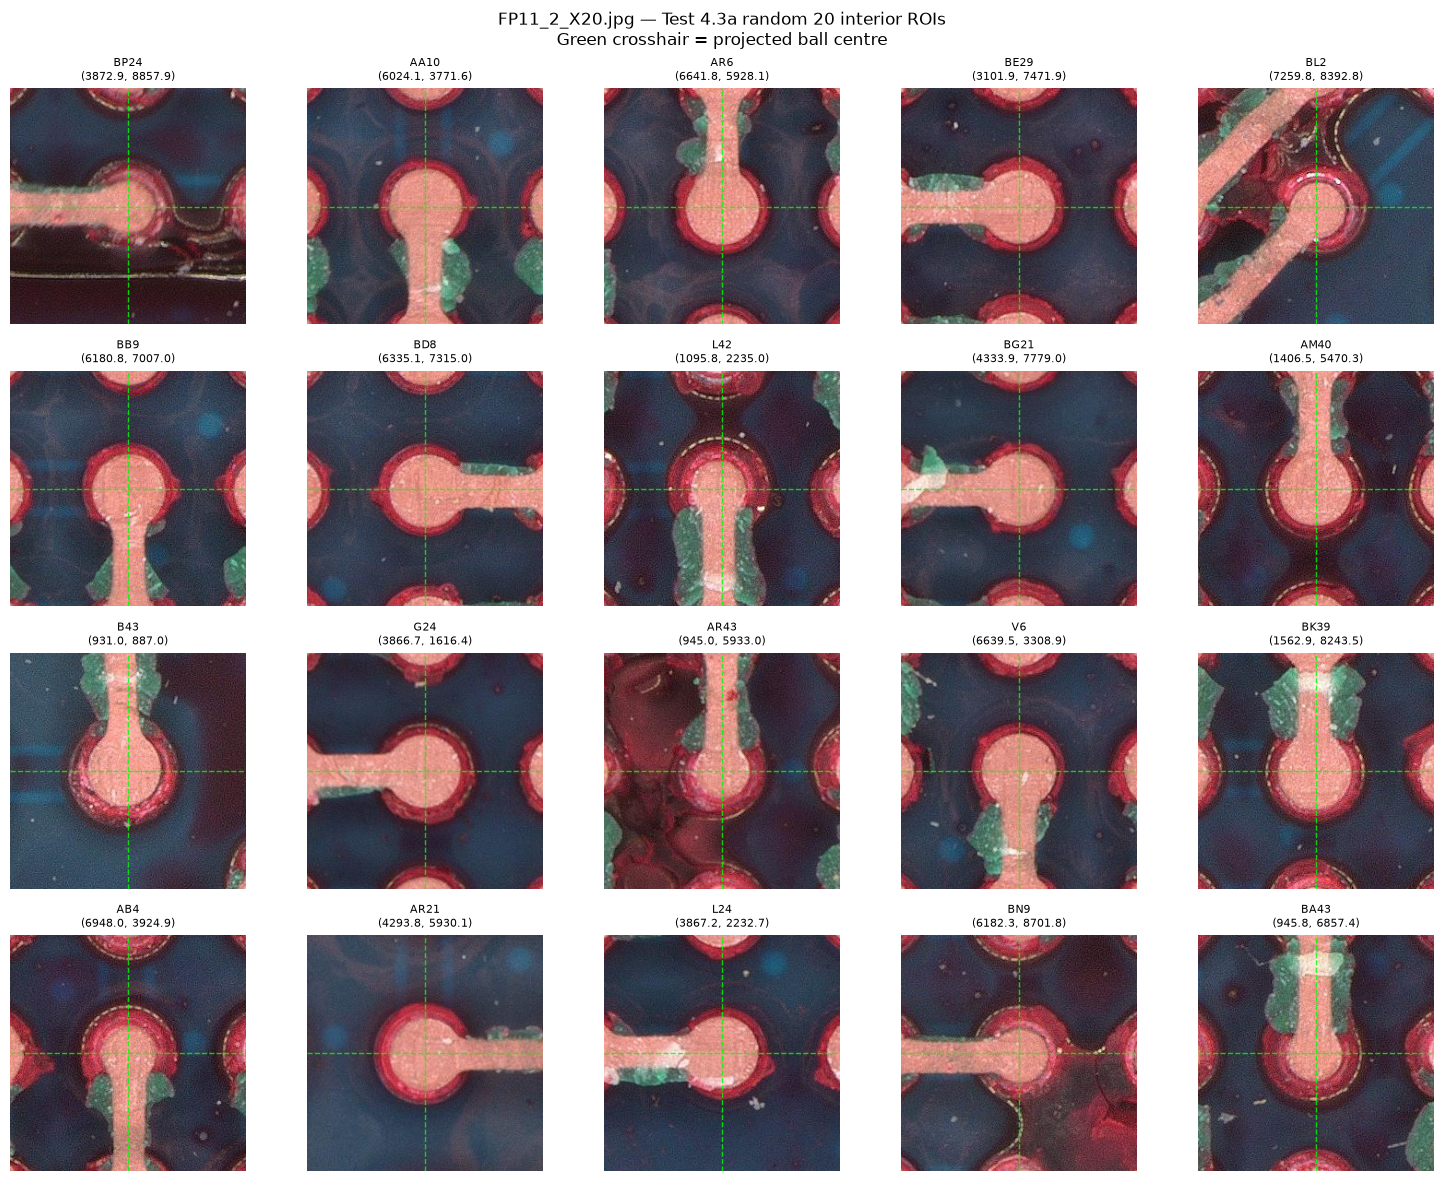

[REVIEW] Confirm all 20 random crops are centred on a solder ball.
Sample IDs: BP24, AA10, AR6, BE29, BL2, BB9, BD8, L42, BG21, AM40, B43, G24, AR43, V6, BK39, AB4, AR21, L24, BN9, BA43


In [6]:
rng = np.random.default_rng(43)   # deterministic sample for repeatable review
sample_ids = list(rng.choice(summary_ref["interior"], size=min(20, summary_ref["n_interior"]), replace=False))

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.ravel()
half = ROI_SIZE // 2

for ax, ball_id in zip(axes, sample_ids):
    roi = rois_ref[ball_id]["roi"]
    meta = rois_ref[ball_id]["meta"]
    roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
    ax.imshow(roi_rgb)
    ax.axvline(half, color="lime", lw=1, ls="--", alpha=0.8)
    ax.axhline(half, color="lime", lw=1, ls="--", alpha=0.8)
    cx, cy = meta["centre_px"]
    ax.set_title(f"{ball_id}\n({cx:.1f}, {cy:.1f})", fontsize=8)
    ax.axis("off")

for ax in axes[len(sample_ids):]:
    ax.axis("off")

plt.suptitle(f"{REF_IMAGE} — Test 4.3a random 20 interior ROIs\nGreen crosshair = projected ball centre", fontsize=12)
plt.tight_layout()
plt.show()

print("[REVIEW] Confirm all 20 random crops are centred on a solder ball.")
print("Sample IDs:", ", ".join(sample_ids))


## 6. Test 4.3b — boundary crop check

Boundary crops are ROIs whose 256 × 256 window extends beyond the source image. They are
black-padded to keep shape consistent and flagged in metadata for downstream notebooks.


In [7]:
boundary_ids = summary_ref["boundary"][:20]

if boundary_ids:
    n_cols = 5
    n_rows = int(np.ceil(len(boundary_ids) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, ball_id in zip(axes, boundary_ids):
        roi = rois_ref[ball_id]["roi"]
        meta = rois_ref[ball_id]["meta"]
        roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
        ax.imshow(roi_rgb)
        pad = f"L{meta['pad_left']} R{meta['pad_right']} T{meta['pad_top']} B{meta['pad_bottom']}"
        ax.set_title(f"{ball_id}\n{pad}", fontsize=8, color="red")
        ax.axis("off")

    for ax in axes[len(boundary_ids):]:
        ax.axis("off")

    plt.suptitle(f"{REF_IMAGE} — Test 4.3b boundary ROIs\nBlack padding marks image-edge crop area", fontsize=12)
    plt.tight_layout()
    plt.show()
    print(f"[REVIEW] Displayed {len(boundary_ids)} boundary crops. Confirm only expected edge padding/partial occlusion is present.")
else:
    print(f"[INFO] No boundary crops found for {REF_IMAGE}; all ROI windows fit inside the image.")


[INFO] No boundary crops found for FP11_2_X20.jpg; all ROI windows fit inside the image.


## 7. Automated ROI validation gates


In [8]:
print("=" * 64)
print("TEST 4.3 — ROI ALIGNMENT / SHAPE GATES")
print("=" * 64)

gate_count = summary_ref["n_total"] == len(df)
print(f"[{'PASS' if gate_count else 'FAIL'}] Gate 1: extracted {summary_ref['n_total']}/{len(df)} ROIs")

gate_shape = summary_ref["shapes_ok"]
print(f"[{'PASS' if gate_shape else 'FAIL'}] Gate 2: all ROIs are {ROI_SIZE}×{ROI_SIZE}×3")

centres_in_bounds = (
    (all_px_ref[:, 0] >= 0) & (all_px_ref[:, 0] < w_px) &
    (all_px_ref[:, 1] >= 0) & (all_px_ref[:, 1] < h_px)
)
gate_centres = bool(centres_in_bounds.all())
print(f"[{'PASS' if gate_centres else 'FAIL'}] Gate 3: projected centres in image bounds "
      f"({centres_in_bounds.sum()}/{len(centres_in_bounds)})")

boundary_fixed_shape = all(rois_ref[bid]["roi"].shape == (ROI_SIZE, ROI_SIZE, 3)
                           for bid in summary_ref["boundary"])
gate_boundary = boundary_fixed_shape
print(f"[{'PASS' if gate_boundary else 'FAIL'}] Gate 4: boundary crops flagged and padded "
      f"({summary_ref['n_boundary']} boundary crops)")

all_gates = gate_count and gate_shape and gate_centres and gate_boundary
print("=" * 64)
print("PASS — automated ROI gates cleared; complete visual review above." if all_gates else "REVIEW — one or more ROI gates failed.")
print("=" * 64)


TEST 4.3 — ROI ALIGNMENT / SHAPE GATES
[PASS] Gate 1: extracted 2077/2077 ROIs
[PASS] Gate 2: all ROIs are 256×256×3
[PASS] Gate 3: projected centres in image bounds (2077/2077)
[PASS] Gate 4: boundary crops flagged and padded (0 boundary crops)
PASS — automated ROI gates cleared; complete visual review above.


## 8. Batch extraction for all images

Register each image independently, extract all ROIs in memory, and save a small inspection
sample to `output/rois/<image_stem>/`. This avoids committing thousands of generated crops
while still providing files that are easy to open outside the notebook.


In [9]:
ROI_DIR.mkdir(parents=True, exist_ok=True)

all_rois = {}
batch_records = []
SAVE_INTERIOR_PER_IMAGE = 50

for img_path in sorted(IMG_DIR.glob("*.jpg")):
    img = cv2.imread(str(img_path))
    assert img is not None, f"Could not read {img_path}"
    h_i, w_i = img.shape[:2]

    res_i = register_image(img, coord_bv)
    rois_i = extract_rois_for_image(img, coord_bv, res_i["M"], df, ROI_SIZE)
    summary_i = summarise_rois(rois_i, ROI_SIZE)
    all_px_i = project_coords(coord_bv, res_i["M"])
    centres_in_bounds_i = bool(((all_px_i[:, 0] >= 0) & (all_px_i[:, 0] < w_i) &
                                (all_px_i[:, 1] >= 0) & (all_px_i[:, 1] < h_i)).all())

    img_roi_dir = ROI_DIR / img_path.stem
    img_roi_dir.mkdir(parents=True, exist_ok=True)
    save_ids = summary_i["interior"][:SAVE_INTERIOR_PER_IMAGE] + summary_i["boundary"]
    for ball_id in save_ids:
        cv2.imwrite(str(img_roi_dir / f"{ball_id}.png"), rois_i[ball_id]["roi"])

    med_i = float(np.median(res_i["residual_full"]))
    p90_i = float(np.percentile(res_i["residual_full"], 90))
    all_rois[img_path.name] = {
        "rois": rois_i,
        "summary": summary_i,
        "registration": res_i,
        "saved_dir": img_roi_dir,
        "saved_ids": save_ids,
    }
    batch_records.append({
        "image": img_path.name,
        "rois": summary_i["n_total"],
        "interior": summary_i["n_interior"],
        "boundary": summary_i["n_boundary"],
        "shapes_ok": summary_i["shapes_ok"],
        "centres_in_bounds": centres_in_bounds_i,
        "median_px": round(med_i, 2),
        "p90_px": round(p90_i, 2),
        "saved_png": len(save_ids),
    })

batch_df = pd.DataFrame(batch_records)
print(batch_df.to_string(index=False))

all_batch_ok = (
    (batch_df["rois"] == len(df)).all() and
    batch_df["shapes_ok"].all() and
    batch_df["centres_in_bounds"].all()
)
print(f"\n[{'PASS' if all_batch_ok else 'FAIL'}] Batch ROI extraction for {len(batch_df)} images")
print(f"Sample crops saved under {ROI_DIR.relative_to(REPO_ROOT)}/")


         image  rois  interior  boundary  shapes_ok  centres_in_bounds  median_px  p90_px  saved_png
FP11_2_X20.jpg  2077      2077         0       True               True       5.04    8.40         50
FP11_3_X20.jpg  2077      2077         0       True               True       4.25    9.16         50
FP11_4_X20.jpg  2077      2077         0       True               True       4.92   12.37         50
FP11_5_X20.jpg  2077      2077         0       True               True       5.07   13.56         50
FP11_6_X20.jpg  2077      2077         0       True               True       3.21    7.89         50

[PASS] Batch ROI extraction for 5 images
Sample crops saved under output\rois/


## 9. Summary

**Outputs consumed by `04_segmentation_prototype.ipynb`:**

- `extract_roi()` — crop one 256 × 256 px BGR ROI around a projected ball centre.
- `extract_rois_for_image()` — crop all 2077 balls for one image-specific registration.
- `all_rois` — dictionary keyed by image filename. Each entry contains `rois`, `summary`,
  `registration`, `saved_dir`, and `saved_ids`.
- `rois[ball_id]["meta"]["is_boundary"]` — flag for image-edge crops with black padding.

**Test 4.3 checklist:**

- Automated gates confirm one fixed-shape ROI per ball and valid projected centres.
- Manual review still matters: inspect the 20 random interior crops and boundary crop grid
  above before marking AGENTS.md Test 4.3 complete.

**Next step:** `04_segmentation_prototype.ipynb` can load these ROIs and run segmentation
on centred solder-ball crops.
